In [2]:
import torch

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from functools import partial
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from src.io import load_data
from src.feature import variance_feature, annotate_labels, our_feature
from src.learning import random_fit_and_eval, RMSE, MAPE
from src.utils import (
    diff_cycles,
    savgol_smooth,
    nankurtosis,
    nanmax,
    nanmin,
    nanmean,
    nanskew,
    nanvar
)

plt.rcParams['font.size'] = 14
%load_ext autoreload
%autoreload 2


In [2]:
import pickle
cell_file = '/data/Blob_EastUS/xiaofan/battery/all_temp_new/data/raw/0131-2_6.pkl'
with open(cell_file, 'rb') as f:
    cell_data = pickle.load(f)

In [3]:
# data_folder = Path.cwd().parent / 'data/raw'
data_folder = '/data/Blob_EastUS/xiaofan/battery/all_temp_new/data/raw'
data = load_data(data_folder)

fixed_labels = annotate_labels(data, label_mode='fixed')
relative_labels = annotate_labels(data, label_mode='relative')

Loading cells:   0%|          | 0/151 [00:40<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# 电压突然下降的点
# 电流几c如何确定


In [ ]:

import numpy as np
import pandas as pd
from typing import List, Tuple, Optional

def _segment_sse(prefix_sum_y, prefix_sum_y2, i, j):
    n = j - i
    if n <= 0:
        return 0.0
    sum_y = prefix_sum_y[j] - prefix_sum_y[i]
    sum_y2 = prefix_sum_y2[j] - prefix_sum_y2[i]
    mean = sum_y / n
    sse = sum_y2 - 2*mean*sum_y + n*(mean**2)
    return sse

def _estimate_noise_sigma(y: np.ndarray) -> float:
    dy = np.diff(y)
    if len(dy) == 0:
        return 0.0
    mad = np.median(np.abs(dy - np.median(dy)))
    if mad == 0:
        s = np.std(dy) / np.sqrt(2)
        return float(s)
    sigma = (mad / 0.6745) / np.sqrt(2)
    return float(sigma)

def detect_steps(y: np.ndarray,
                    penalty: Optional[float] = None,
                    max_steps: Optional[int] = None
                    ) -> Tuple[List[int], List[Tuple[int,int,float]]]:
    y = np.asarray(y, dtype=float)
    n = len(y)
    if n == 0:
        return [], []
    ps_y = np.zeros(n+1); ps_y2 = np.zeros(n+1)
    ps_y[1:] = np.cumsum(y); ps_y2[1:] = np.cumsum(y**2)
    if penalty is None:
        sigma = _estimate_noise_sigma(y)
        penalty = (sigma**2) * np.log(max(n,2))
        if penalty == 0:
            penalty = 1e-6
    dp = np.zeros(n+1); prev = np.zeros(n+1, dtype=int)
    dp[0] = -penalty
    for j in range(1, n+1):
        best = 1e300; best_i = 0
        for i in range(0, j):
            cost = dp[i] + _segment_sse(ps_y, ps_y2, i, j) + penalty
            if cost < best:
                best = cost; best_i = i
        dp[j] = best; prev[j] = best_i
    cps = []; j = n
    while j > 0:
        i = prev[j]; cps.append(j); j = i
    cps = cps[::-1]
    segs = []; start = 0
    for end in cps:
        mean = (ps_y[end]-ps_y[start])/(end-start)
        segs.append((int(start), int(end), round(float(mean), 1))); start = end
    if max_steps is not None and len(segs) > max_steps:
        def seg_sse(a,b): return _segment_sse(ps_y, ps_y2, a,b)
        while len(segs) > max_steps:
            best_merge = 1e300; best_k = 0
            for k in range(len(segs)-1):
                a1,b1,_ = segs[k]; a2,b2,_ = segs[k+1]
                merge_cost = seg_sse(a1,b2) - (seg_sse(a1,b1)+seg_sse(a2,b2))
                if merge_cost < best_merge: best_merge = merge_cost; best_k = k
            a1,b1,_ = segs[best_k]; a2,b2,_ = segs[best_k+1]
            a,b = a1,b2; mean = (ps_y[b]-ps_y[a])/(b-a)
            segs[best_k:best_k+1] = [(a,b,round(float(mean), 1))]; del segs[best_k+1]
        cps = [b for _,b,_ in segs]
    return cps, segs

def summarize_segments(x: np.ndarray, segments: List[Tuple[int,int,float]]):
    import pandas as pd
    rows = []
    for (a,b,mean) in segments:
        rows.append({
            "start_idx": a,
            "end_idx": b,
            "length": b-a,
            "plateau_value": mean
        })
    return pd.DataFrame(rows)

# # Example noisy sequence (like your W_c)
# y = np.array(data['0131-2_6'][1]['W_c'])
# x = np.arange(len(y))

# # --- Detect step changes ---
# cps, segments = detect_steps(y, penalty=2)  # auto penalty
# summary = summarize_segments(x, segments)
# print(summary)

# # --- Plot for visual check ---
# plt.plot(x, y, 'b.-', label='raw W_c')
# for cp in cps[:-1]:
#     plt.axvline(cp, color='orange', linestyle='--', lw=1)
# for a,b,m in segments:
#     plt.hlines(m, a, b, colors='r', lw=2)
# plt.legend()
# plt.show()


In [ ]:
cycle_idx = 1
seg_data = []
for id, cell_name in enumerate(data.keys()):
    # if id>100:
    #     break
    y = np.array(data[cell_name][1]['W_c'])
    cps, segments = detect_steps(y, penalty=2)  # auto penalty
    # print(cell_name, segments)
    segments = [i for i in segments if (i[1]-i[0]) > 1]
    
    # if len(segments) > 2:
    #     print(cell_name, segments)
    cur_seg = [cell_name]
    if len(segments) > 0:
        cur_seg.append(segments[0][2])
    else:
        cur_seg.append(np.nan)
    change_voltage = np.nan    
    if len(segments) > 1:
        change_voltage = round(data[cell_name][1]['V_c'][segments[1][0]], 1)
        cur_seg.append(segments[1][2])
    else:
        
        cur_seg.append(np.nan)
    cur_seg.append(float(change_voltage))
        # voltage
    seg_data.append(cur_seg)

    

In [ ]:
seg_df = pd.DataFrame(data=seg_data, columns=['cell_name', 'w1', 'w2', 'change_voltage'])

In [ ]:
seg_df['rul'] = seg_df['cell_name'].apply(lambda x: fixed_labels[x])


In [ ]:
seg_df

,cell_name,w1,w2,change_voltage,date,temp,cell_tag,rul
0,0131-2_6,15.0,8.0,4.0,0131,-10,0131(-10),1
1,0131-2_7,15.0,8.0,4.1,0131,-10,0131(-10),1
2,0131-2_8,15.0,7.0,4.1,0131,-10,0131(-10),1
3,0131-3_2,15.0,7.0,4.1,0131,-10,0131(-10),1
4,0131-3_3,15.0,5.5,4.1,0131,-10,0131(-10),1
...,...,...,...,...,...,...,...,...
146,1227-6_1,16.5,10.0,4.1,1227,55,1227(55),471
147,1227-6_2,16.5,10.0,4.1,1227,55,1227(55),445
148,1227-6_3,16.5,8.5,4.1,1227,55,1227(55),543
149,1227-6_4,16.5,8.5,4.1,1227,55,1227(55),435


In [188]:
seg_df[seg_df['date'] == '0202']

,cell_name,w1,w2,change_voltage,date,temp,cell_tag,rul,cluster,charge_time
29,0202-1_1,16.5,11.5,3.9,0202,25,0202(25),2,2,1657
30,0202-1_2,16.5,11.5,3.8,0202,25,0202(25),1,3,1637
31,0202-1_3,16.5,11.5,3.8,0202,25,0202(25),1,2,1623
32,0202-1_4,16.5,10.5,3.9,0202,25,0202(25),5,2,1746
33,0202-1_5,16.5,10.5,3.9,0202,25,0202(25),1,2,1722
34,0202-1_6,16.5,10.5,3.9,0202,25,0202(25),3,1,1747
35,0202-1_7,16.5,10.0,3.9,0202,25,0202(25),9,6,1766
36,0202-1_8,16.5,10.0,4.0,0202,25,0202(25),1,1,1667
37,0202-2_1,16.5,10.0,4.0,0202,25,0202(25),4,1,1755
38,0202-2_2,16.5,10.0,4.0,0202,25,0202(25),3,3,1686


In [ ]:
date_tag_group_temps = [
    '-10C-0131', '-10C-0131', '-10C-0131', '-10C-0131', '-10C-0131', '-10C-0131', '-10C-0131',
    '0C-1130', '0C-1130', '0C-1130', '0C-1130', '0C-1130', '0C-1130', '0C-1130',
    '10C-0201', '10C-0201', '10C-0201', '10C-0201', '10C-0201', '10C-0201', '10C-0201',
    '25C-0202', '25C-0202', '25C-0202', '25C-0202', '25C-0202', '25C-0202', '25C-0202',
    '30C-0829', '30C-0829', '30C-0829', '30C-0829', '30C-0829', '30C-0829', '30C-0829',
    '30C-1013', '30C-1013', '30C-1013', '30C-1013', '30C-1013', '30C-1013', '30C-1013',
    '55C-1227', '55C-1227', '55C-1227', '55C-1227', '55C-1227', '55C-1227', '55C-1227',
    '70C-0909', '70C-0909', '70C-0909', '70C-0909', '70C-0909', '70C-0909', '70C-0909', '70C-0909',
]

In [ ]:

def build_temp_map(date_tag_group_temps):
    date_temp_map = {}
    for s in date_tag_group_temps:
        date = s[-4:]
        temp = int(s.split('C')[0])
        if date not in date_temp_map.keys():
            date_temp_map[date] = temp
    return date_temp_map

In [ ]:
date_temp_map = build_temp_map(date_tag_group_temps)

In [ ]:
seg_df['date'] = seg_df['cell_name'].apply(lambda x: x.split('-')[0])
seg_df['temp'] = seg_df['date'].apply(lambda x: date_temp_map[x])
seg_df['cell_tag'] = seg_df.apply(lambda x: f'{x['date']}({x['temp']})', axis=1)

In [ ]:
charge_time_map = {}
for id, cell_name in enumerate(data.keys()):
    charge_time_map[cell_name] = int(data[cell_name][1]['t_c'].max())
seg_df['charge_time'] = seg_df['cell_name'].apply(lambda x: charge_time_map[x])


In [170]:
seg_df.to_csv('./output/charge_protocol.csv')

In [3]:
import pandas as pd
seg_df= pd.read_csv('../output/charge_protocol.csv')

In [ ]:
# import pickle

# # Read the object from the pickle file named '219951.pkl'
# with open('/data/Blob_EastUS/xiaofan/battery/all_temp_new/data/clusters.pkl', 'rb') as file:
#     clusters = pickle.load(file)

In [4]:
import json
# Read the dictionary from the JSON file
with open('../data/cluster_group_detail.json', 'r') as json_file:
    loaded_data = json.load(json_file)

In [5]:
cluter_map = {}
for k,v in loaded_data.items():
    for i in v:
        cluter_map[i] = k

In [6]:
seg_df['cluster'] = seg_df['cell_name'].apply(lambda x: cluter_map[x] if x in cluter_map else np.nan)

In [7]:
seg_df

,Unnamed: 0,cell_name,w1,w2,change_voltage,date,temp,cell_tag,rul,cluster,charge_time
0,0,0131-2_6,15.0,8.0,4.0,131,-10,0131(-10),1,2,1010
1,1,0131-2_7,15.0,8.0,4.1,131,-10,0131(-10),1,NaN,1186
2,2,0131-2_8,15.0,7.0,4.1,131,-10,0131(-10),1,NaN,897
3,3,0131-3_2,15.0,7.0,4.1,131,-10,0131(-10),1,NaN,1141
4,4,0131-3_3,15.0,5.5,4.1,131,-10,0131(-10),1,NaN,1862
...,...,...,...,...,...,...,...,...,...,...,...
146,146,1227-6_1,16.5,10.0,4.1,1227,55,1227(55),471,NaN,1825
147,147,1227-6_2,16.5,10.0,4.1,1227,55,1227(55),445,NaN,1818
148,148,1227-6_3,16.5,8.5,4.1,1227,55,1227(55),543,7,1916
149,149,1227-6_4,16.5,8.5,4.1,1227,55,1227(55),435,NaN,1915


In [8]:
seg_df = seg_df[seg_df['w2'].isnull()==False]

In [9]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt



# # --- Melt the data so that 'w1', 'w2', 'change_voltage' become one column ---
# df_melt = seg_df.melt(
#     id_vars=["cell_tag"],
#     value_vars=["w1", "w2", "change_voltage"],
#     var_name="parameter",
#     value_name="value"
# )
# # y="value"
# y="change_voltage"

# plt.figure(figsize=(12,5))
# sns.boxplot(
#     data=seg_df,
#     x="cell_tag",
#     y=y,
#     # hue="parameter",
#     palette="Set2"
# )

# plt.title("Distribution of w1, w2, and change_voltage by Date")
# plt.xlabel("Date")
# plt.ylabel("Value")

# # Move legend outside
# plt.legend(title="Parameter", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()


In [10]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(4, 1, figsize=(8, 12), sharex=True)

# # 1️⃣ Step 1 charging power
# sns.stripplot(data=df, x="date", y="w1", ax=axes[0],
#               jitter=True, size=6, color="skyblue")
# # sns.swarmplot(data=df, x="date", y="w1", ax=axes[0], size=6, color="skyblue")
# # sns.swarmplot(data=df, x="date", y="w1", hue="w1", ax=axes[0], palette="coolwarm")
 
# axes[0].set_title("Step 1 Charging Power by Date")
# axes[0].set_ylabel("Value")

# # 2️⃣ Step 2 charging power
# sns.stripplot(data=df, x="date", y="w2", ax=axes[1],
#               jitter=True, size=6, color="salmon")
# axes[1].set_title("Step 2 Charging Power by Date")
# axes[1].set_ylabel("Value")

# # 3️⃣ Change voltage
# sns.stripplot(data=df, x="date", y="change_voltage", ax=axes[2],
#               jitter=True, size=6, color="lightgreen")
# axes[2].set_title("Step1&2 Change Voltage by Date")
# axes[2].set_ylabel("Value")

# # 4️⃣ Changing time (if you have a column for it)
# sns.stripplot(data=df, x="date", y="charge_time", ax=axes[3],
#               jitter=True, size=6, color="mediumseagreen")
# axes[3].set_title("Charging Time by Date")
# axes[3].set_ylabel("Value")

# # Common X label
# axes[3].set_xlabel("Date")

# plt.tight_layout()
# plt.show()


In [9]:
df

,Unnamed: 0,cell_name,w1,w2,change_voltage,date,temp,cell_tag,rul,cluster,charge_time
0,0,0131-2_6,15.0,8.0,4.0,131,-10,0131(-10),1,2.0,1010
1,1,0131-2_7,15.0,8.0,4.1,131,-10,0131(-10),1,NaN,1186
2,2,0131-2_8,15.0,7.0,4.1,131,-10,0131(-10),1,NaN,897
3,3,0131-3_2,15.0,7.0,4.1,131,-10,0131(-10),1,NaN,1141
4,4,0131-3_3,15.0,5.5,4.1,131,-10,0131(-10),1,NaN,1862
...,...,...,...,...,...,...,...,...,...,...,...
146,146,1227-6_1,16.5,10.0,4.1,1227,55,1227(55),471,NaN,1825
147,147,1227-6_2,16.5,10.0,4.1,1227,55,1227(55),445,NaN,1818
148,148,1227-6_3,16.5,8.5,4.1,1227,55,1227(55),543,7.0,1916
149,149,1227-6_4,16.5,8.5,4.1,1227,55,1227(55),435,NaN,1915


In [13]:
seg_df[seg_df['cell_tag'] == '1013(30)']

,Unnamed: 0,cell_name,w1,w2,change_voltage,date,temp,cell_tag,rul,cluster,charge_time,temp_tag
89,89,1013-4_1,16.5,11.5,3.8,1013,30,1013(30),251,3,1772,30°C B2
90,90,1013-4_2,16.5,11.5,3.8,1013,30,1013(30),133,1,1784,30°C B2
91,91,1013-4_3,16.5,11.5,3.8,1013,30,1013(30),207,3,1770,30°C B2
92,92,1013-4_4,16.5,10.5,3.9,1013,30,1013(30),248,1,1800,30°C B2
93,93,1013-4_5,16.5,10.5,3.9,1013,30,1013(30),191,2,1774,30°C B2
94,94,1013-4_6,16.5,10.5,3.9,1013,30,1013(30),92,1,1803,30°C B2
95,95,1013-4_7,16.5,10.0,4.0,1013,30,1013(30),124,1,1823,30°C B2
96,96,1013-4_8,16.5,10.0,4.0,1013,30,1013(30),111,1,1829,30°C B2
97,97,1013-5_1,16.5,10.0,3.9,1013,30,1013(30),235,1,1797,30°C B2
98,98,1013-5_2,16.5,10.0,4.0,1013,30,1013(30),127,0,1762,30°C B2


In [29]:
seg_df['temp_tag'].unique()

array(['-10°C', '10°C', '25°C', '30°C', '70°C', '30°C Batch 2', '0°C',
       '55°C'], dtype=object)

In [12]:
seg_df['temp_tag'] = seg_df['temp'].apply(lambda x : f'{x}°C')
change_idx = seg_df[seg_df['cell_tag'] == '1013(30)'].index.values
seg_df.loc[change_idx, 'temp_tag'] = "30°C B2"

/tmp/ipykernel_2865232/3540160891.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  seg_df['temp_tag'] = seg_df['temp'].apply(lambda x : f'{x}°C')


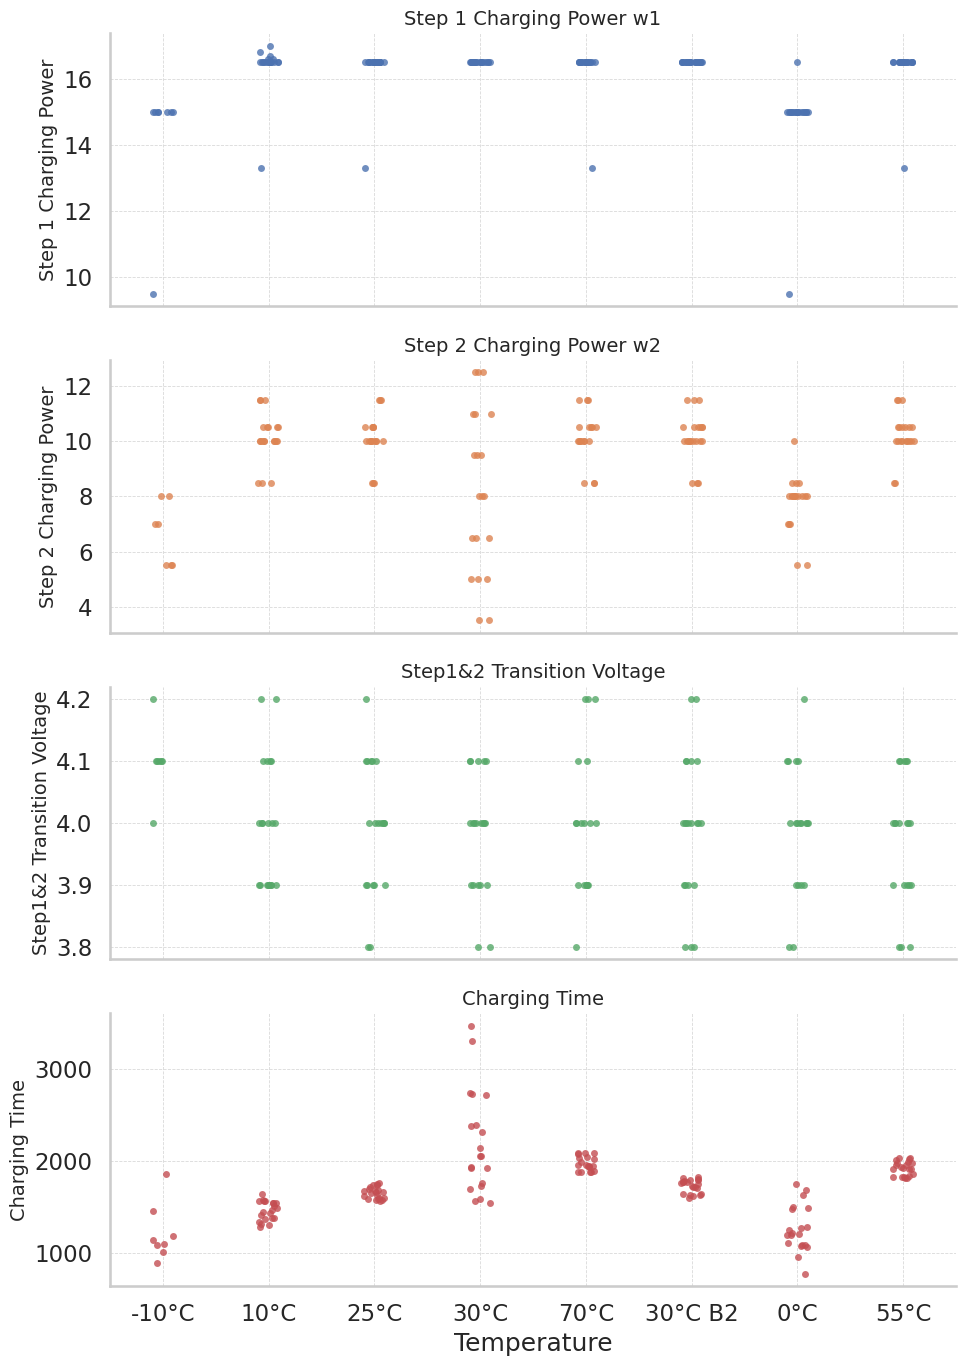

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
df=seg_df.copy()
# Apply Nature-like aesthetics
sns.set_theme(style="whitegrid", context="talk", font_scale=1.0)
# Muted or deep palettes give that subtle scientific look
palette = sns.color_palette("deep")

fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)

# Step 1 charging power
sns.stripplot(data=df, x="temp_tag", y="w1", ax=axes[0],
              jitter=True, size=5, color=palette[0], alpha=0.8)
axes[0].set_title("Step 1 Charging Power w1", fontsize=14)
axes[0].set_ylabel("Step 1 Charging Power", fontsize=14)

# Step 2 charging power
sns.stripplot(data=df, x="temp_tag", y="w2", ax=axes[1],
              jitter=True, size=5, color=palette[1], alpha=0.8)
axes[1].set_title("Step 2 Charging Power w2", fontsize=14)
axes[1].set_ylabel("Step 2 Charging Power", fontsize=14)

# Step1&2 change voltage
sns.stripplot(data=df, x="temp_tag", y="change_voltage", ax=axes[2],
              jitter=True, size=5, color=palette[2], alpha=0.8)
axes[2].set_title("Step1&2 Transition Voltage", fontsize=14)
axes[2].set_ylabel("Step1&2 Transition Voltage", fontsize=14)

# Charging time
sns.stripplot(data=df, x="temp_tag", y="charge_time", ax=axes[3],
              jitter=True, size=5, color=palette[3], alpha=0.8)
axes[3].set_title("Charging Time", fontsize=14)
axes[3].set_ylabel("Charging Time", fontsize=14)
axes[3].set_xlabel("Temperature")

# Clean look
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(color="0.85", linestyle="--", linewidth=0.6)

plt.tight_layout()
# plt.show()
plt.savefig('./output/dotplot.png')

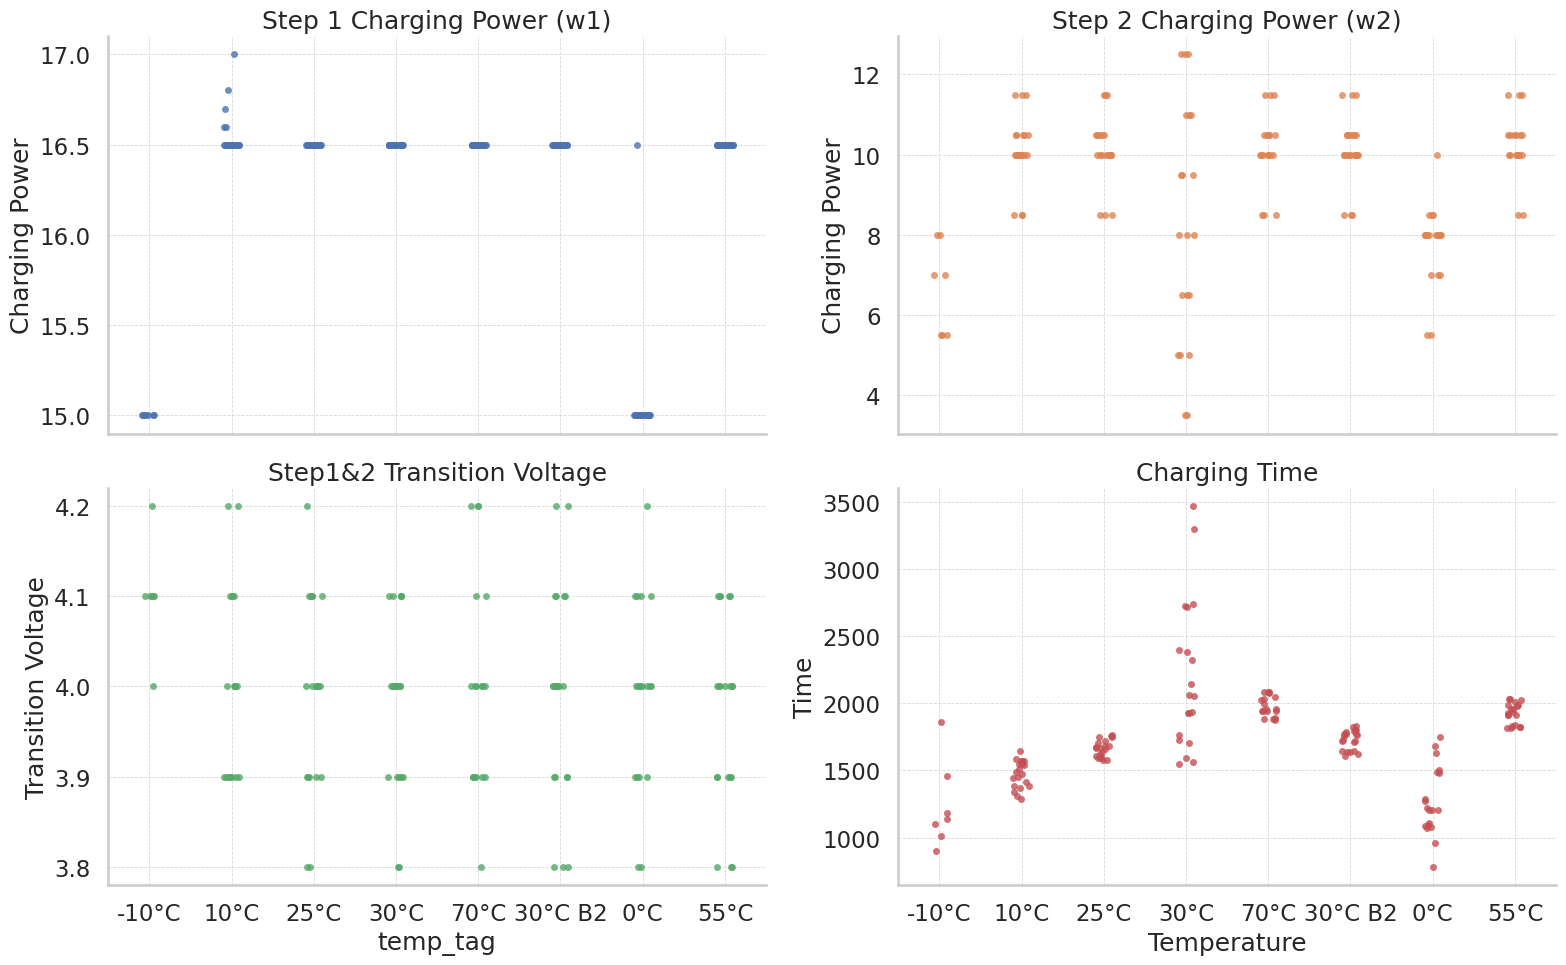

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
df=seg_df.copy()

# Nature-like aesthetics
sns.set_theme(style="whitegrid", context="talk", font_scale=1.0)
palette = sns.color_palette("deep")

# ★ 改成2行2列
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

# Step 1 charging power
sns.stripplot(data=df, x="temp_tag", y="w1", ax=axes[0,0],
              jitter=True, size=5, color=palette[0], alpha=0.8)
axes[0,0].set_title("Step 1 Charging Power (w1)")
axes[0,0].set_ylabel("Charging Power")

# Step 2 charging power
sns.stripplot(data=df, x="temp_tag", y="w2", ax=axes[0,1],
              jitter=True, size=5, color=palette[1], alpha=0.8)
axes[0,1].set_title("Step 2 Charging Power (w2)")
axes[0,1].set_ylabel("Charging Power")

# Step1&2 change voltage
sns.stripplot(data=df, x="temp_tag", y="change_voltage", ax=axes[1,0],
              jitter=True, size=5, color=palette[2], alpha=0.8)
axes[1,0].set_title("Step1&2 Transition Voltage")
axes[1,0].set_ylabel("Transition Voltage")

# Charging time
sns.stripplot(data=df, x="temp_tag", y="charge_time", ax=axes[1,1],
              jitter=True, size=5, color=palette[3], alpha=0.8)
axes[1,1].set_title("Charging Time")
axes[1,1].set_ylabel("Time")
axes[1,1].set_xlabel("Temperature")

# Beautify
for ax in axes.flatten():
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(color="0.85", linestyle="--", linewidth=0.6)

plt.tight_layout()
plt.savefig('../output/dotplot_2x2.png')


# Heat map

In [182]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

df = seg_df.copy()

# Encode the categorical label
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['cluster'])



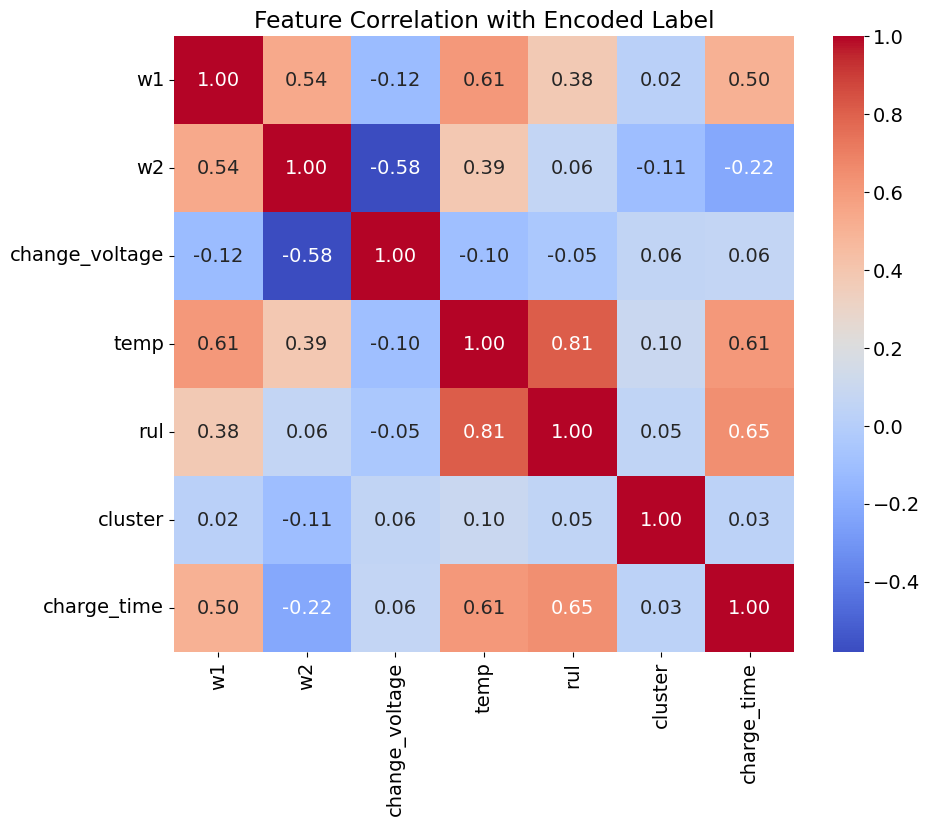

In [187]:
sel_col = ['w1', 'w2', 'change_voltage', 'temp', 'rul', 'cluster', 'charge_time']
# Calculate the correlation matrix
correlation_matrix = df[sel_col].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with Encoded Label')
plt.show()

In [221]:
seg_df[seg_df['date'] == '1013'].to_csv('./output/charging_protocol_example.csv')

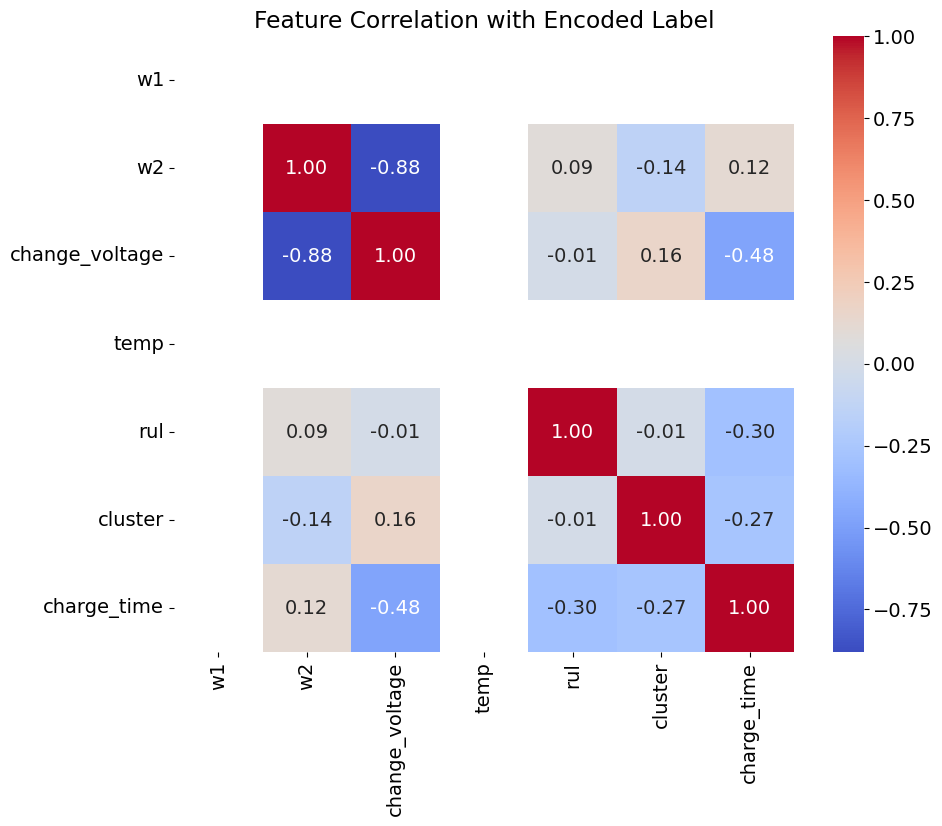

In [199]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

df = seg_df[seg_df['date'] == '1013'].copy()

# Encode the categorical label
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['cluster'])


sel_col = ['w1', 'w2', 'change_voltage', 'temp', 'rul', 'cluster', 'charge_time']
# Calculate the correlation matrix
correlation_matrix = df[sel_col].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with Encoded Label')
plt.show()

In [8]:
import pickle

In [2]:
# dir_path = '/data/Blob_EastUS/xiaofan/battery/all_temp_new/data/raw'
# import os
# for i in os.listdir(dir_path):
#     print(i)
#     raw_path = os.path.join(dir_path, i)
#     with open(raw_path, 'rb') as f:
#         cell_data = pickle.load(f)
#         print(len(cell_data[1]['t_c']), len(cell_data[1]['t_d']))
        

In [6]:
scores = {}
seeds = list(range(16))  # Randomness for dataset split and model initialization
evaluators = [RMSE(log_scale=True), MAPE(log_scale=True)]
num_early_cycles = 50

smoother = partial(savgol_smooth, window=51, order=3)


In [8]:
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mtick

# # --- Figure & axis -----------------------------------------------------------
# plt.rcParams.update({
#     "font.family": "sans-serif",
#     "font.size"  : 12,        # labels & tick text
# })

# fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# # --- Plot --------------------------------------------------------------------
# ax.plot(
#     cycle_info["V_d"],          # x
#     cycle_info["Q_d"],          # y
#     lw=1,                       # thicker line
#     color="tab:blue",
# )
# ax.scatter(cycle_info["V_d"], cycle_info["Q_d"] , s=5, color='black')

# # --- Axes styling ------------------------------------------------------------
# ax.set_xlabel("Voltage (V)")
# ax.set_ylabel("Capacity (Ah)")   # change units if appropriate

# # ax.invert_xaxis()                # typical for dQ/dV or Q–V curves
# # ax.xaxis.set_major_locator(mtick.MultipleLocator(0.2))
# # ax.yaxis.set_major_locator(mtick.MultipleLocator(0.1))

# ax.grid(True, which="both", ls="--", lw=0.4, alpha=0.5)

# # Remove top/right borders (optional)
# for spine in ["top", "right"]:
#     ax.spines[spine].set_visible(False)
# # plt.gca().set_xticklabels([])
# # plt.gca().set_yticklabels([])
# # fig.tight_layout()
# # plt.savefig('orgin_VQ.svg', format='svg')
# # plt.show()


In [9]:
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mtick

# # --- Figure & axis -----------------------------------------------------------
# plt.rcParams.update({
#     "font.family": "sans-serif",
#     "font.size"  : 12,        # labels & tick text
# })

# fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# # --- Plot --------------------------------------------------------------------
# ax.plot(
#     # cycle_info["V_d"],          # x
#     cycle_info["QV_d"] *cycle_info['Q_base'],          # y
#     lw=2,                       # thicker line
#     color="tab:blue",
# )
# # ax.scatter(cycle_info["V_d"], cycle_info["Q_d"] , s=5, color='black')


# # --- Axes styling ------------------------------------------------------------
# ax.set_xlabel("Voltage (V)")
# ax.set_ylabel("Capacity (Ah)")   # change units if appropriate

# # ax.invert_xaxis()                # typical for dQ/dV or Q–V curves
# # ax.xaxis.set_major_locator(mtick.MultipleLocator(0.2))
# # ax.yaxis.set_major_locator(mtick.MultipleLocator(0.1))

# ax.grid(True, which="both", ls="--", lw=0.4, alpha=0.5)

# # Remove top/right borders (optional)
# for spine in ["top", "right"]:
#     ax.spines[spine].set_visible(False)


# # plt.gca().set_xticklabels([])
# # plt.gca().set_yticklabels([])
# # fig.tight_layout()
# # plt.savefig('interpolate_VQ.svg', format='svg')


In [11]:

y_relative = np.array([
    label for _, label in relative_labels.items() if label > num_early_cycles
])

X_relative = torch.stack([
    torch.stack([
        torch.stack([
            cycle_data['VQ_c'], cycle_data['VQ_d'],
            cycle_data['dVdQ_c'], cycle_data['dVdQ_d'], 
            cycle_data['interp_I_c'], cycle_data['interp_I_d'],
            cycle_data['interp_V_c'], cycle_data['interp_V_d'],
            cycle_data['QV_c'], cycle_data['QV_d'],
            cycle_data['interp_E_c'], cycle_data['interp_E_d'],
            cycle_data['interp_W_c'], cycle_data['interp_W_d']
        ]) for cycle_data in data[cell][:50]
    ]) for cell, label in relative_labels.items() if label > num_early_cycles
]).permute(0, 2, 1, 3).contiguous()


In [12]:
X_qdlinear = np.stack([
    np.stack([
        cycle_data['Q_d(V_d)'][-1]
        for cycle_data in data[cell][:50]
    ]) 
    for cell, label in relative_labels.items() if label > num_early_cycles
])
X_qdlinear.shape

(95, 50, 100)

In [13]:
def print_score(model_score):
    mean_score = np.mean(model_score, axis=0).squeeze(), np.std(model_score, axis=0).squeeze()
    train_RMSE, test_RMSE, train_RMSE_variance, test_RMSE_variance =  mean_score[0][0][0], mean_score[0][0][1], mean_score[1][0][0], mean_score[1][0][1]
    train_MAPE, test_MAPE, train_MAPE_variance, test_MAPE_variance  =  mean_score[0][1][0], mean_score[0][1][1], mean_score[1][1][0], mean_score[1][1][1]
    print(f'train_RMSE:{train_RMSE:.2f} ± {train_RMSE_variance:.0f}, test_RMSE:{test_RMSE:.2f} ± {test_RMSE_variance:.0f}' )
    print(f'train_MAPE:{train_MAPE:.2f} ± {train_MAPE_variance:.0f}, test_MAPE:{test_MAPE:.2f} ± {test_MAPE_variance:.0f}' )

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_hist(test_label, train_label, fraction=0.7, bins=10, is_save=False, file_path=None):
    sns.set(style="whitegrid")

    # Create the distribution plot
    plt.figure()
    sns.histplot(train_label, kde=True, bins=bins, label='train')
    sns.histplot(test_label, kde=True, bins=bins, label='test')
    

    # sns.histplot(data_800, kde=True, bins=30, label=800)
    # Add labels and title

    plt.xlabel(f'RUL')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of RUL for Training and Testing Sets (Seed 0)')
    plt.legend()
    plt.tight_layout()
    if is_save == True and file_path:
        plt.savefig(file_path)
    # Show the plot
    plt.show()

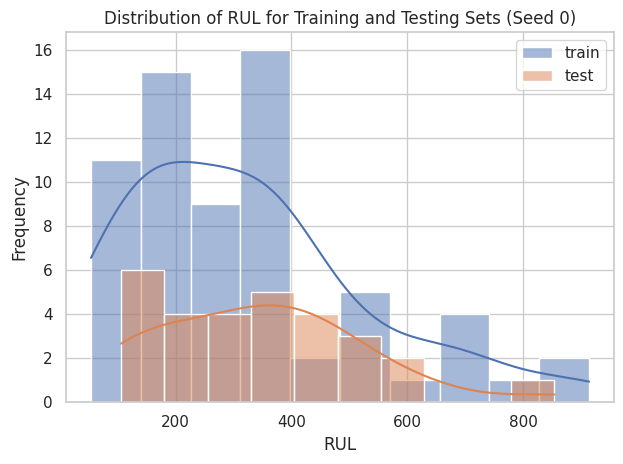

In [ ]:
from src.learning import random_fit_and_eval_new
X, y = X_qdlinear, y_relative
y_train, y_test = random_fit_and_eval_new(
            X.reshape(len(X), -1),
            y_relative,
            models=[DummyRegressor()],
            evaluators=evaluators,
            seed=0,
            return_prediction=True,
            return_train_loss=True
        )
plot_hist(y_test, y_train)

# Dummy

In [25]:
evaluators = [RMSE(log_scale=True), MAPE(log_scale=True)]
predictions = {}
scores = {}
key = 'dummy'
scores[key] = []
predictions[key] = []
X, y = X_qdlinear, y_relative
for seed in seeds:
    score, y_test, y_pred = random_fit_and_eval(
            X.reshape(len(X), -1),
            np.log(y_relative),
            models=[DummyRegressor()],
            evaluators=evaluators,
            seed=seed,
            return_prediction=True,
            return_train_loss=True
        )
    scores[key].append(score)
    predictions[key].append([y_test, y_pred])
print(f'model: {key}')
print_score(scores[key])


ValueError: not enough values to unpack (expected 3, got 2)

# Variance model

In [36]:

X_diff = X_qdlinear[:, 48, :] - X_qdlinear[:, 8, :]
y = y_relative
Vdlin = np.linspace(4.2, 3.74, 100)
functions = {
    # 'Training set mean':            lambda x: np.mean(train_logrul) * np.ones((len(x), )),
    
    'IQR($\Delta Q_{100-10}$)' :    lambda x: np.percentile(x, 75, axis=1) - np.percentile(x, 25, axis=1),
    'Percentile($\Delta Q_{100-10}$)' :  lambda x: np.percentile(x, 62, axis=1) - np.percentile(x, 31, axis=1),
    '$\Delta Q_{100-10}' + f'({Vdlin[43]:0.3f}$V)':  lambda x: x[:, 43],
    'variance model':   lambda x:np.var(x,axis=1),
}
for k, func in enumerate(functions):
    # print(k, func)
    key = func
    scores[key] = []
    predictions[key] = []
    X = np.log10(np.abs(functions[func](X_diff))).reshape(-1, 1)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    
    for seed in seeds:
        score, y_test, y_pred = random_fit_and_eval(X, np.log(y), [LinearRegression()], evaluators, seed=seed, need_normalize=False, return_prediction=True, return_train_loss=True)
        scores[key].append(score)
        predictions[key].append([y_test, y_pred])

    print(f'model: {key}')
    print_score(scores[key])
    print('\n')


<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'


/tmp/ipykernel_3665156/701117183.py:7: SyntaxWarning: invalid escape sequence '\D'
  'IQR($\Delta Q_{100-10}$)' :    lambda x: np.percentile(x, 75, axis=1) - np.percentile(x, 25, axis=1),
/tmp/ipykernel_3665156/701117183.py:8: SyntaxWarning: invalid escape sequence '\D'
  'Percentile($\Delta Q_{100-10}$)' :  lambda x: np.percentile(x, 62, axis=1) - np.percentile(x, 31, axis=1),
/tmp/ipykernel_3665156/701117183.py:9: SyntaxWarning: invalid escape sequence '\D'
  '$\Delta Q_{100-10}' + f'({Vdlin[43]:0.3f}$V)':  lambda x: x[:, 43],


model: IQR($\Delta Q_{100-10}$)
train_RMSE:201.65 ± 13, test_RMSE:200.96 ± 29
train_MAPE:67.10 ± 5, test_MAPE:76.12 ± 15


model: Percentile($\Delta Q_{100-10}$)
train_RMSE:201.45 ± 13, test_RMSE:200.76 ± 29
train_MAPE:66.98 ± 5, test_MAPE:76.09 ± 15


model: $\Delta Q_{100-10}(4.000$V)
train_RMSE:198.08 ± 12, test_RMSE:194.97 ± 30
train_MAPE:60.44 ± 4, test_MAPE:66.42 ± 12


model: variance model
train_RMSE:201.37 ± 13, test_RMSE:200.56 ± 29
train_MAPE:66.87 ± 5, test_MAPE:75.99 ± 15




# Discharge model

In [48]:
from scipy.stats import skew, kurtosis
def normalize_discharge_features(data):
    functions = {
        'min' :    lambda x: np.min(x, axis=1),
        'var':     lambda x: np.var(x, axis=1),
        'skew':    lambda x: skew(x, axis=1),
        'kurt':    lambda x: kurtosis(x, axis=1),
    }
    
    DeltaQ_50_minus_10 = X_qdlinear[:, 48, :] - X_qdlinear[:, 8, :]
    X = np.ones((DeltaQ_50_minus_10.shape[0],len(functions)+2))
    for k, func in enumerate(functions):
        feat = functions[func](DeltaQ_50_minus_10)
        X[:,k] = feat
    X[:,-2] = data[:,0,1]
    X[:,-1] = np.amax(data[:,0,:],axis=1)- data[:,0,1]
    X[np.isinf(X)] = 0.0
    return X

key = 'discharge'
scores[key] = []
predictions[key] = []
X = normalize_discharge_features(X_qdlinear)

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

for seed in seeds:
    score, y_test, y_pred = random_fit_and_eval(X, np.log(y), [LinearRegression()], evaluators, seed=seed, need_normalize=True, return_prediction=True, return_train_loss=True)
    scores[key].append(score)
    predictions[key].append([y_test, y_pred])

print(f'model: {key}')
print_score(scores[key])


model: discharge
train_RMSE:194.52 ± 12, test_RMSE:205.54 ± 28
train_MAPE:59.78 ± 4, test_MAPE:77.01 ± 15


# Full model

In [49]:
def f_cycle_resistance(cycle_info):
    return np.ma.masked_invalid(cycle_info['V_d']/cycle_info['I_d']).mean() 
def get_slope_intercept(y):
    x = np.linspace(1, len(y), len(y))
    z = np.polyfit(x, y, 1)
    return z
def construct_battery_cycle_fullmodel_data(data_tages, data, date_tag2temp,  num_cycles=50):
    # q_d_all = None
    q_d_all = []
    date_sel = []
    charge_times = []
    temperatures = []
    resistances = None
    
    for date_tag in data_tages:
        cycle_infos = data[date_tag]
        # get capacity(discharge)

        q_ds = [cycle_info['Q_d'][-1].tolist() for cycle_info in cycle_infos]   
        q_metrics = np.expand_dims(np.array(q_ds[:num_cycles]), axis=0)
        if isinstance(q_d_all, np.ndarray):
            q_d_all = np.append(q_d_all, q_metrics, axis=0)
        else:
            q_d_all = q_metrics
            
        # get charge time of first 5 cycles
        charge_time= np.mean([len(cycle_info['t_c']) for cycle_info in cycle_infos[:5]])
        charge_times.append(charge_time)
        
        # get temperature
        temperatures.append(int(date_tag2temp[date_tag].split('C')[0]))
        
        # get resistance
        rs = [f_cycle_resistance(cycle_info)  for cycle_info in cycle_infos[:50]]
        
        rs_metrics = np.expand_dims(np.array([np.min(rs),rs[-1] - rs[1]]), axis=0)
        
        if isinstance(resistances, np.ndarray):
            resistances = np.append(resistances, rs_metrics, axis=0)
        else:
            resistances = rs_metrics
            
    return q_d_all, np.array(date_sel), np.array(charge_times), np.array(temperatures), resistances

def build_fullmodel_features(battery_tags,
                            date_tag2cycle_infos,
                            date_tag2temp=None,
                            num_cycles=50):
    functions = {
        'min' :    lambda x: np.min(x, axis=1),
        'var':     lambda x: np.var(x, axis=1),
    }    
    qds,_,charge_times, temperatures, resistances = construct_battery_cycle_fullmodel_data(battery_tags,
                                                                                            date_tag2cycle_infos,date_tag2temp,
                                                                                            num_cycles=num_cycles)
    DeltaQ_50_minus_10_all = X_qdlinear[:, 48, :] - X_qdlinear[:, 8, :]

    X = np.ones((DeltaQ_50_minus_10_all.shape[0],len(functions)+7))

    for k, func in enumerate(functions):
        feat = functions[func](np.nan_to_num(DeltaQ_50_minus_10_all))
        X[:,k] = feat
    # Discharge capacity fade curve features
    # 3.Slope of the linear fit to the capacity fade curve, cycles 2 to 100 ---- linear_fit[0]
    # 4.Intercept of the linear fit to capacity fade curve, cycles 2 to 100 ---- linear_fit[1]
    linear_fit = np.array([get_slope_intercept(qd) for qd in qds])
    # 5.Discharge capacity, cycle 2 ---- capacity2
    capacity2 = qds[:,1]
    # 6.Average charge time, first 5 cycles ------charge_times
    # 7.Integral of temperature over time, cycles 2 to 100  ------ temperatures
    # 8.Minimum internal resistance, cycles 2 to 100-------resistances[0]
    # 9.Internal resistance, difference between cycle 100 and cycle 2 -------resistances[1]
    X[:,2:4] = linear_fit
    X[:,4] = capacity2
    X[:,5] = charge_times
    X[:,6] = temperatures
    X[:,7:] = resistances

    return X



In [50]:
import json
import numpy as np
with open('../data/date_tag2temp.json', 'r') as json_file:
    date_tag2temp = json.load(json_file)
data_tags = [cell for cell, label in relative_labels.items() if label > num_early_cycles]

X = build_fullmodel_features(data_tags,data,date_tag2temp, num_cycles=50)

key = 'full'
scores[key] = []
predictions[key] = []
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

for seed in seeds:
    score, y_test, y_pred = random_fit_and_eval(X, np.log(y), [LinearRegression()], evaluators, seed=seed, need_normalize=True, return_prediction=True, return_train_loss=True)
    scores[key].append(score)
    predictions[key].append([y_test, y_pred])

print(f'model: {key}')
print_score(scores[key])

/tmp/ipykernel_3349229/2608701130.py:2: RuntimeWarning: divide by zero encountered in divide
  return np.ma.masked_invalid(cycle_info['V_d']/cycle_info['I_d']).mean()


model: full
train_RMSE:133.60 ± 10, test_RMSE:156.37 ± 24
train_MAPE:25.46 ± 2, test_MAPE:32.43 ± 5


# Tree based models

In [51]:
from src.learning import tree_models_fit_and_eval
X = X_qdlinear[:, 48, :] - X_qdlinear[:, 8, :]
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

res_score, res_pred = tree_models_fit_and_eval(X, np.log(y), evaluators, seeds, need_normalize=True, return_prediction=True, return_train_loss=True)

for key in res_score.keys():
    scores[key] = res_score[key]
    predictions[key] = res_pred[key]

    print(f'model: {key}')
    print_score(scores[key])


Suggested number of components: 4
Suggested number of components:  2
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}
Suggested number of components: 6
Suggested number of components:  1
{'n_estimators': 600, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': 10, 'bootstrap': True}
Suggested number of components: 2
Suggested number of components:  2
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}
Suggested number of components: 10
Suggested number of components:  1
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 20, 'bootstrap': True}
Suggested number of components: 3
Suggested number of components:  1
{'n_estimators': 1200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 90, 'bootstrap': True}
Suggested n

In [53]:
for key in res_score.keys():
    print(f'model: {key}')
    print_score(scores[key])
    print('\n')


model: Ridge
train_RMSE:190.73 ± 45, test_RMSE:232.73 ± 132
train_MAPE:62.92 ± 16, test_MAPE:80.39 ± 21


model: Elastic net
train_RMSE:129.90 ± 15, test_RMSE:169.92 ± 26
train_MAPE:30.85 ± 4, test_MAPE:48.82 ± 9


model: PCR
train_RMSE:152.92 ± 15, test_RMSE:164.13 ± 31
train_MAPE:40.22 ± 5, test_MAPE:48.28 ± 6


model: PLSR
train_RMSE:225.77 ± 19, test_RMSE:225.13 ± 29
train_MAPE:79.90 ± 9, test_MAPE:87.70 ± 16


model: RF
train_RMSE:67.95 ± 22, test_RMSE:166.82 ± 29
train_MAPE:11.94 ± 5, test_MAPE:40.33 ± 7




# MLP

In [54]:
from src.learning import MLP_rul_estimator, random_fit_and_eval_nn
key = 'MLP'
scores[key] = []
predictions[key] = []
X = X_qdlinear[:, 48, :] - X_qdlinear[:, 8, :]
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)


for seed in seeds:
    score, pred = random_fit_and_eval_nn(X, np.log(y), [MLP_rul_estimator], evaluators, seed=seed,need_zscore=True, return_prediction=True , return_train_loss=True)
    scores[key].append(score)
    predictions[key].append(pred[0])

print(f'model: {key}')
print_score(scores[key])

model: MLP
train_RMSE:88.39 ± 12, test_RMSE:225.83 ± 29
train_MAPE:16.47 ± 2, test_MAPE:59.85 ± 12


# CNN

In [55]:
from src.learning import CNN_rul_estimator, random_fit_and_eval_nn
key = 'CNN'
scores[key] = []
predictions[key] = []
X = X_qdlinear[:, :, :] - X_qdlinear[:, 8, :][:, np.newaxis, :]

# check for outliers and set values equal to zero
X[np.where(X > 1)] = 0
X[np.where(X < -0.2)] = 0

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)



for seed in seeds:
    score, pred = random_fit_and_eval_nn(X, np.log(y), [CNN_rul_estimator], evaluators, seed=seed,need_zscore=True , return_prediction=True, return_train_loss=True)
    scores[key].append(score)
    predictions[key].append(pred[0])
    
print(f'model: {key}')
print_score(scores[key])

model: CNN
train_RMSE:2.26 ± 1, test_RMSE:153.16 ± 29
train_MAPE:0.42 ± 0, test_MAPE:29.57 ± 5


# Our model

In [40]:

from src.feature import our_feature
X_add =np.array([[
        [cycle_data['Q_d'][-1], cycle_data['Q_c'][-1]]
         for cycle_data in data[cell][:50]]
     for cell, label in relative_labels.items() if label > num_early_cycles]
)

def get_slope_intercept(y):
    x = np.linspace(1, len(y), len(y))
    z = np.polyfit(x, y, 1)
    return z

intercept = []
for i in range(X_add.shape[0]):
    intercept.append([get_slope_intercept(X_add[i, :, 0]), get_slope_intercept(X_add[i, :, 1])])
intercept = np.array(intercept)
intercept = intercept.reshape(intercept.shape[0], -1)

import json
with open('./data/date_tag2temp.json', 'r') as json_file:
    date_tag2temp = json.load(json_file)
# data_tags = [cell for cell, label in relative_labels.items() if label > num_early_cycles]

X_temp = np.array([int(date_tag2temp[cell].split('C')[0]) for cell, label in relative_labels.items() if label > num_early_cycles])
X_temp = X_temp.reshape(X_temp.shape[0], -1)

task_type = 'relative'

X, y = eval(f'X_{task_type}'), eval(f'y_{task_type}')
key = 'Ours'
X_ours, fea_names = our_feature(
    X,
    num_cycle_groups=7,
    num_signal_segments=4,
    aggregators=[
        nankurtosis, nanmax, nanmin, nanmean, nanvar, nanskew
    ],
    activators=[
        lambda x: x,  # identity
        torch.abs
    ],
    build_feature_name= True,
    device='cuda:0'
)
X_ours = np.concatenate([X_ours, intercept], axis=1)
fea_names.extend(['Qd_intercept_k','Qd_intercept_b','Qc_intercept_k','Qc_intercept_b'])
print(X_ours.shape, len(fea_names))
X_ours = np.nan_to_num(X_ours, nan=0.0, posinf=0.0, neginf=0.0)


scores[key] = []
predictions[key] = []
feature_importances = []
for seed in tqdm(seeds, desc=f'Processing {key}'):
    score, test_y, test_pred = random_fit_and_eval(
        X_ours, np.log(y), [RandomForestRegressor()], evaluators, seed=seed, return_prediction= True, return_train_loss=True
    )
    # score, feature_importance= random_fit_and_eval(
    #     X_ours, np.log(y), [RandomForestRegressor()], evaluators, seed=seed, feature_name= fea_names, return_train_loss=True
    # )
    scores[key].append(score)
    predictions[key].append(test_pred)

print(f'model: {key}')
print_score(scores[key])

0: torch.Size([95, 14, 7, 8, 4, 250])
1: torch.Size([95, 84, 7, 4, 250])
2: torch.Size([95, 84, 28, 4, 250])
3: torch.Size([95, 504, 28, 4])
(95, 112900) 112900


Processing Ours: 100%|██████████| 16/16 [47:27<00:00, 177.96s/it]

model: Ours
train_RMSE:63.96 ± 6, test_RMSE:137.67 ± 27
train_MAPE:9.22 ± 1, test_MAPE:26.87 ± 4


In [30]:
# import pickle
# with open('../output/rul_baseline_scores_with_trainloss.pkl', 'wb') as f:
#     pickle.dump(scores, f)

In [76]:
import pickle
with open('../output/rul_baseline_scores.pkl', 'wb') as f:
    pickle.dump(scores, f)

In [77]:
import pickle
with open('../output/rul_baseline_predictions.pkl', 'wb') as f:
    pickle.dump(predictions, f)

In [ ]:
# # save feature importance(figure 3c data)
# import pandas as pd
# fea_imp_data = []
# for seed in range(16):
#     for item in range(20):
#         # print(feature_importances[seed][0][item])
#         fea_imp_data.append([seed, feature_importances[seed][0][item][0], feature_importances[seed][0][item][1]])

# fea_imp = pd.DataFrame(fea_imp_data, columns= ['seed', 'feature_name', 'score'])
# fea_imp.to_csv('../output/feature_importance_rul_v2_cycle7.csv')


In [61]:
# save rul result to csv
table = []
columns = ['model','Train RMSE mean', 'Train RMSE var', 'Test RMSE mean', 'Test RMSE var','Train MAPE mean', 'Train MAPE var', 'Test MAPE mean', 'Test MAPE var']
for key in scores.keys():
    mean = np.mean(scores[key], axis=0).squeeze()
    std = np.std(scores[key], axis=0).squeeze()

    table.append([key, mean[0][0], std[0][0], mean[0][1], std[0][1], mean[1][0], std[1][0], mean[1][1], std[1][1]])
import pandas as pd
result_df = pd.DataFrame(data=table, columns=columns)
result_df["Train RMSE"] = result_df.apply(lambda x: f'{x["Train RMSE mean"]:.2f} ± {x["Train RMSE var"]:.0f}', axis=1)
result_df["Test RMSE"] = result_df.apply(lambda x: f'{x["Test RMSE mean"]:.2f} ± {x["Test RMSE var"]:.0f}', axis=1)

result_df["Train MAPE"] = result_df.apply(lambda x: f'{x["Train MAPE mean"]:.2f} ± {x["Train MAPE var"]:.0f}', axis=1)
result_df["Test MAPE"] = result_df.apply(lambda x: f'{x["Test MAPE mean"]:.2f} ± {x["Test MAPE var"]:.0f}', axis=1)
result_df.to_csv('../output/rul_result.csv')


In [62]:
result_df

,model,Train RMSE mean,Train RMSE var,Test RMSE mean,Test RMSE var,Train MAPE mean,Train MAPE var,Test MAPE mean,Test MAPE var,Train RMSE,Test RMSE,Train MAPE,Test MAPE
0,dummy,203.134811,12.154343,201.065250,28.887598,67.538099,4.782769,75.335884,14.087980,203.13 ± 12,201.07 ± 29,67.54 ± 5,75.34 ± 14
1,IQR($\Delta Q_{100-10}$),201.651440,12.676576,200.963270,29.391738,67.099646,4.963870,76.121547,14.617702,201.65 ± 13,200.96 ± 29,67.10 ± 5,76.12 ± 15
2,Percentile($\Delta Q_{100-10}$),201.446507,12.686250,200.758371,29.396101,66.975500,5.007179,76.089733,14.667789,201.45 ± 13,200.76 ± 29,66.98 ± 5,76.09 ± 15
3,$\Delta Q_{100-10}(4.000$V),198.083403,12.104242,194.973832,29.750986,60.435122,4.202508,66.418591,11.583464,198.08 ± 12,194.97 ± 30,60.44 ± 4,66.42 ± 12
4,log 10 (var(ΔQ100−10 (V))),201.369140,12.561115,200.564685,29.277580,66.867512,4.923524,75.991538,14.517059,201.37 ± 13,200.56 ± 29,66.87 ± 5,75.99 ± 15
5,variance model,201.369140,12.561115,200.564685,29.277580,66.867512,4.923524,75.991538,14.517059,201.37 ± 13,200.56 ± 29,66.87 ± 5,75.99 ± 15
6,discharge,194.518024,12.134357,205.540412,28.051679,59.776774,4.365243,77.012919,15.013498,194.52 ± 12,205.54 ± 28,59.78 ± 4,77.01 ± 15
7,full,133.603623,9.657945,156.367022,23.513141,25.462375,1.519148,32.428540,5.325984,133.60 ± 10,156.37 ± 24,25.46 ± 2,32.43 ± 5
8,Ridge,190.730431,45.470946,232.726216,132.050929,62.923172,15.774443,80.386768,21.345038,190.73 ± 45,232.73 ± 132,62.92 ± 16,80.39 ± 21
9,Elastic net,129.902910,15.030695,169.916577,26.258038,30.845703,3.907817,48.815793,8.734797,129.90 ± 15,169.92 ± 26,30.85 ± 4,48.82 ± 9
